# Task 1: Condition Classification
Can a classifier identify which treatment condition a cell came from using its gene expression profile? Which genes drive the separation?
Train one or more classification model**s (logistic regression, tree ensembles or neural networ**k), depending on group size
:
a) One student: Choose one type of model,
b) Groups with two students: Choose two types of models.
c) Groups with three students: Train one of e
ach.
For each model you train, compute feature importance and discuss the results

## Experimental setup
Design your experiment appropriately, e.g., using one of the data splitting strategies presented in Lecture 4. Justify your choices.
Evaluate the influence of relevant model parameters and justify your choices. For example, for k-means clustering, you might set k = 3 and mention that you expect the data to be separable into three classes based on your previous PCA plot, or you might train several models with different k and evaluate which one is best for the task using suitable metrics.
## Model evaluation
We expect you to design your models carefully to improve their performance. However, for your grade, how well the model actually performs is less important than a sensible and thorough evaluation of the model’s performance, using suitable metrics.
For tasks 1 and 3: If multiple models are trained, compare results of your models, including in the context of the bias-variance tradeoff. Give a hypothesis describing the differences you see between models.

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
    classification_report,
)

In [3]:
INPUT_FILE = '/home/ubuntu/data/frangieh/rna.qc.clust.h5ad'
sc.settings.verbosity = 1
RNG = 0
np.random.seed(RNG)

In [4]:
adata = ad.read_h5ad(INPUT_FILE)

In [5]:
adata

AnnData object with n_obs × n_vars = 176242 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions'

## Exploration

In [6]:
original_columns = [ 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 
                    'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 
                    'disease', 'perturbation_type', 'celltype', 'organism', 
                    'perturbation_type_2', 'nperts', 'ngenes']
adata.obs[original_columns]

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,perturbation_type,celltype,organism,perturbation_type_2,nperts,ngenes
cell_name,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3520
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3531
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4086
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,3178
CELL_6,10X 3' v3 sequencing,Control,1,IFNGR1_1,8810.0,IFNGR1_1,IFNGR1,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_218326,10X 3' v3 sequencing,Co-culture,1,AHNAK_2,16010.0,AHNAK_2,AHNAK,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4151
CELL_218327,10X 3' v3 sequencing,Co-culture,4,nan,12722.0,CTSO_3;PIK3IP1_3;VDAC2_2;WNT7A_1,CTSO,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3686
CELL_218328,10X 3' v3 sequencing,Co-culture,2,nan,11643.0,JAK2_3;SLC7A5P1_3,JAK2,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3462


Following the example workflow from Lecture 4, we start of by looking into the class counts in our dataset and look for potential class imbalance. The labels are stored in the column `perturbation_2`.

In [7]:
# Class raw counts
print(adata.obs['perturbation_2'].value_counts())

perturbation_2
IFNγ          76727
Co-culture    53701
Control       45814
Name: count, dtype: int64


In [8]:
# Class fractions
print(adata.obs['perturbation_2'].value_counts()/adata.n_obs)

perturbation_2
IFNγ          0.435350
Co-culture    0.304700
Control       0.259949
Name: count, dtype: float64


From these outputs, we see that the majority of cells in our dataset are from IFNy culture, followed by the cells from the co-culture and the Control cells having the lowes number, about 26% of the entire dataset.

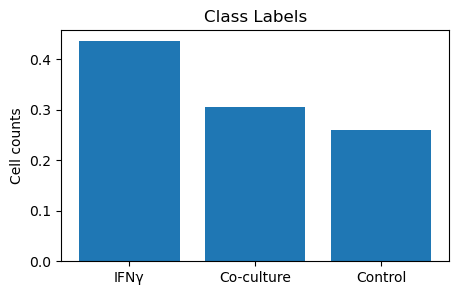

In [9]:
plt.figure(figsize=(5, 3))
plt.bar([1,2,3], adata.obs['perturbation_2'].value_counts()/adata.n_obs)
plt.title('Class Labels')
plt.ylabel("Cell counts")
plt.xticks([1,2,3], adata.obs['perturbation_2'].value_counts().index.to_list())
plt.show()

## Feature Selection

Since we labeled the 5000 most variable genes during the preprocessing, we can use those to reduce the feature space.

In [10]:
adata = adata[:,adata.var['highly_variable']==True].copy()
adata

AnnData object with n_obs × n_vars = 176242 × 5000
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions',

## Data Prep

In [11]:
# Function adatpted from Lecture 4
def data_prep(adata, y_col):
    """
    Prepare X and Y for classification from a given AnnData object.
    -------------------------------------------------
    Args:
        adata (AnnData Object): AnnData object of the dataset.
        y_col (str): A string indicating the column in adata.obs to be used as a label.
    Returns:
        X (numpy.array): a numpy array containing the gene expression data from the dataset.
        y (numpy.array): a numpy array containing the labels to be used for training.
    """
    
    if hasattr(adata.X, "toarray"): # Taken from Lecture 4
        X = adata.X.toarray()
    else:
        X = adata.X
    
    y = adata.obs[y_col].to_numpy().astype(str)
    
    return X, y

X_full, y_full = data_prep(adata, y_col='perturbation_2')

In [12]:
print('X: ', X_full) 
print('Y: ', y_full)

X:  [[0.         0.         0.         ... 0.         0.         0.6540299 ]
 [0.         0.         0.         ... 0.         0.         0.65849346]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.61997694]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
Y:  ['Control' 'Control' 'Control' ... 'Co-culture' 'Co-culture' 'Co-culture']


In [13]:
# Y = np.zeros(shape=[adata.n_obs,]) # 'Control' is labeled as 0
# Y[adata.obs['perturbation_2']=='Co-culture'] = 1
# Y[adata.obs['perturbation_2']=='IFNγ'] = 2

# classes = np.unique(Y, return_counts=True)
# print(classes)
# # For comparison the cell counts:
# # IFNγ          76727
# # Co-culture    53701
# # Control       45814

## Quick test

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [15]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        max_iter=1000
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
scores = cross_validate(
    pipe,
    X_full,
    y_full,
    cv=cv,
    scoring=["roc_auc", "average_precision", "neg_log_loss", "accuracy"],
    return_train_score=True
)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 167, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 463, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklea

In [17]:
print("Train AUC:", scores["train_roc_auc"].mean())
print("CV AUC:", scores["test_roc_auc"].mean())
print("Train log loss:", -scores["train_neg_log_loss"].mean())
print("CV log loss:", -scores["test_neg_log_loss"].mean())

Train AUC: nan
CV AUC: nan
Train log loss: 0.0005599741300102324
CV log loss: 0.1190208688378334


In [19]:
scores

{'fit_time': array([24.41057777, 30.26900458, 22.36245203, 23.28602934, 22.49863267]),
 'score_time': array([2.90267444, 2.37473392, 2.34030247, 2.34873414, 2.34058523]),
 'test_roc_auc': array([nan, nan, nan, nan, nan]),
 'train_roc_auc': array([nan, nan, nan, nan, nan]),
 'test_average_precision': array([0.99068003, 0.99262981, 0.99194298, 0.99275555, 0.99197464]),
 'train_average_precision': array([0.99667897, 0.99722147, 0.99711729, 0.99697249, 0.99766696]),
 'test_neg_log_loss': array([-0.1240968 , -0.11289481, -0.12130857, -0.11213601, -0.12466816]),
 'train_neg_log_loss': array([-0.00065377, -0.00039914, -0.00073569, -0.00051435, -0.00049692]),
 'test_accuracy': array([0.9855315 , 0.9860989 , 0.98618361, 0.9858148 , 0.98618361]),
 'train_accuracy': array([0.99995744, 1.        , 0.99997163, 0.99999291, 0.99998581])}

In [18]:
)

SyntaxError: unmatched ')' (687023194.py, line 1)

## Data Scaling

In [ ]:
np.mean(X_full)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

In [ ]:
np.mean(X_scaled)

## Train-Test Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.5, stratify=y_full, random_state=123,
)

In [ ]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print(np.unique(y_train, return_counts=True))
print('X_test: ', X_test.shape)
print('y_test; ', y_test.shape)
print(np.unique(y_test, return_counts=True))

## Fitting a Logisitic Regression model

In [ ]:
model = LogisticRegression(C=1.0, l1_ratio=0.0, random_state=123, verbose=1)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print('y_pred: ', y_pred)
y_prob = model.predict_proba(X_test)
print('y_prob: ', y_prob)

In [ ]:
classes = np.array(sorted(np.unique(y_full)))
print(classes)
predictions = classes[y_prob.argmax(1)]
print(sum(y_pred == predictions) == y_pred.shape)

## Model Evaluation

In [ ]:
def evaluate(y_true, y_pred, y_proba, classes):
    print("accuracy         :", round(accuracy_score(y_true, y_pred), 3))
    print("balanced acc.    :", round(balanced_accuracy_score(y_true, y_pred), 3))
    print("macro AUROC (OvR):", round(roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro", labels=classes), 3))
    # macro AUCPR
    aps = []
    for i, c in enumerate(classes):
        aps.append(average_precision_score((y_true == c).astype(int), y_proba[:, i]))
    print("macro AUCPR      :", round(float(np.mean(aps)), 3))
    print()
    print(classification_report(y_true, y_pred, digits=3))

In [ ]:
(y_test == 'Control').astype(int)

In [ ]:
evaluate(y_test, y_pred, y_prob, classes)

In [ ]:
# print("accuracy         :", round(accuracy_score(y_test, y_pred), 3))
# print("balanced acc.    :", round(balanced_accuracy_score(y_test, y_pred), 3))
# print("macro AUROC (OvR):", round(roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro", labels=classes), 3))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

### Confusion matrix eval

In [ ]:
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    # print(title)
    # print(disp.confusion_matrix)

plt.show()

### AUC Eval

In [ ]:
plt.figure()  
for i, label in enumerate(classes):
    fpr, tpr, thresholds = roc_curve((y_test == label).astype(int), y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} - ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([-0.1, 1.05])
plt.ylim([-0.1, 1.05])
plt.legend()
plt.show()